In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn. metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [3]:
train_data = fetch_20newsgroups(
    subset = "train",
    remove = ("headers", "footers", "quotes")
)

In [4]:
test_data = fetch_20newsgroups(
    subset = "test",
    remove = ("headers", "footers", "quotes")
)

In [5]:
x_train_text = train_data.data
y_train = train_data.target

x_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [6]:
print("Training documents: ", len(x_train_text))
print("Testing documents: ", len(x_test_text))
print("Number of classes: ", len(class_names))

Training documents:  11314
Testing documents:  7532
Number of classes:  20


In [7]:
vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2
)
x_train = vectorizer.fit_transform(x_train_text)
x_test = vectorizer.transform(x_test_text)

In [8]:
print("Training feature matrix: ", x_train.shape)
print("Testing feature matrix: ", x_test.shape)

Training feature matrix:  (11314, 39115)
Testing feature matrix:  (7532, 39115)


In [9]:
mnb = MultinomialNB()
mnb.fit(
    x_train,
    y_train
)
y_pred_mnb = mnb.predict(x_test)

In [10]:
binary_vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2,
    binary = True
)
x_train_binary = binary_vectorizer.fit_transform(x_train_text)
x_test_binary = binary_vectorizer.transform(x_test_text)

In [11]:
bnb = BernoulliNB()
bnb.fit(
    x_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(x_test_binary)

In [13]:
results = pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_mnb),
        accuracy_score(y_test,y_pred_bnb)
    ],
    "Precision":[
        precision_score(y_test,y_pred_mnb,average = "macro"),
        precision_score(y_test,y_pred_bnb,average = "macro"),
    ],
    "Recall":[
        recall_score(y_test,y_pred_mnb,average = "macro"),
        recall_score(y_test,y_pred_bnb,average = "macro"),
    ],
    "F1-Score":[
        f1_score(y_test,y_pred_mnb,average = "macro"),
        f1_score(y_test,y_pred_bnb,average = "macro"),
    ]
})

In [15]:
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial NB,0.651089,0.634470,0.636933,0.617859
1,Bernoulli NB,0.485130,0.616678,0.469434,0.467865


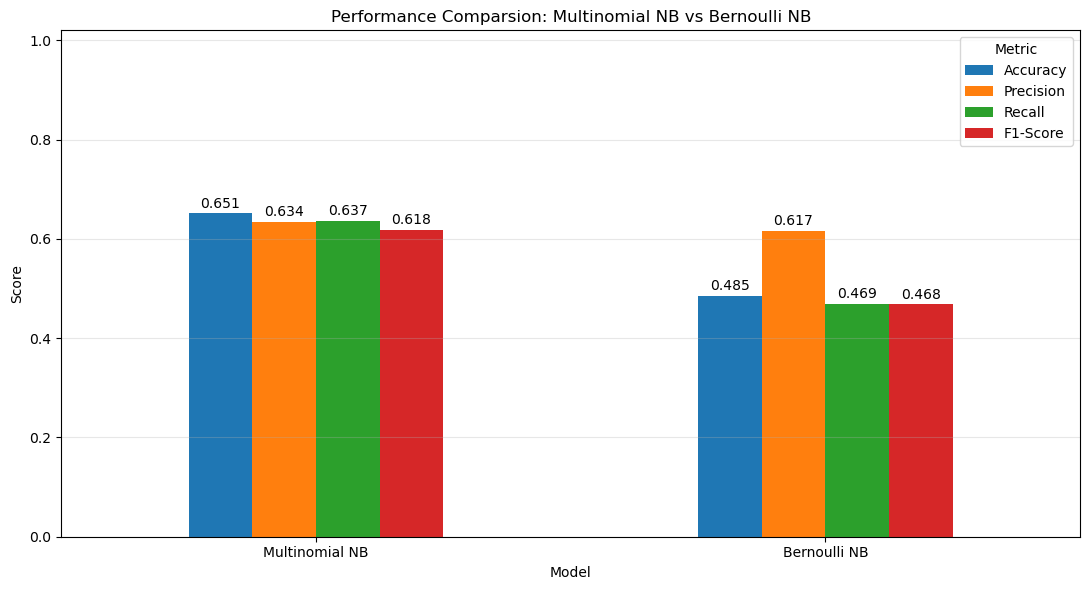

In [22]:
results_metrics = results[
    ["Model","Accuracy", "Precision", "Recall", "F1-Score"]
]

ax = results_metrics.set_index("Model").plot(
    kind = "bar",
    figsize = (11,6)
)

plt.title("Performance Comparsion: Multinomial NB vs Bernoulli NB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
#Display values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.3f",
        padding = 2
    )
plt.tight_layout()
plt.show()